## Sentiment Analysis

In [1]:
import numpy as np
import pandas as pd
import string, re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
# Loading the dataset from the given URL
data_source_url = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
airline_tweets = pd.read_csv(data_source_url)

In [22]:
airline_tweets.head(2)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)


In [23]:
airline_tweets["sentiment_class"]=airline_tweets["airline_sentiment"].map({"negative": 0,"neutral":3,"positive":4})

In [24]:
airline_tweets.shape

(14640, 16)

In [25]:
airline_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [26]:
airline_tweets.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
sentiment_class                     0
dtype: int64

## Pre-defining fix Fig size

In [36]:
plt.rcParams["font.family"] = 'DejaVu Sans'
plt.style.use('ggplot')
plot_size = plt.rcParams["figure.figsize"]
# print(plot_size[0])
# print(plot_size[1])
plot_size[0] = 5
plot_size[1] = 3
plt.rcParams["figure.figsize"] = plot_size

## EDA part

<AxesSubplot:title={'center':'Pie Plot containing different Airlines'}, ylabel='airline'>

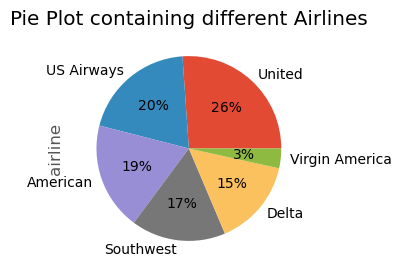

In [37]:
airline_tweets.airline.value_counts().plot(kind='pie',
title='Pie Plot containing different Airlines',autopct='%1.0f%%')

<AxesSubplot:title={'center':'Bar Plot containing different Airlines'}, xlabel='airline'>

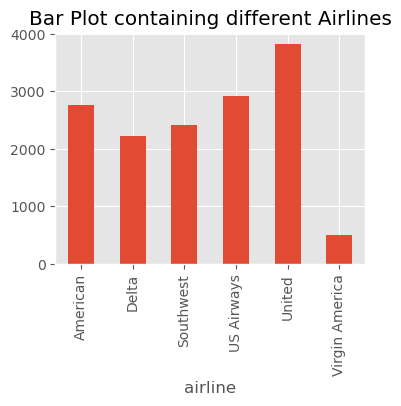

In [45]:
airline_tweets.groupby('airline')['airline'].count().plot(kind='bar',
title='Bar Plot containing different Airlines',figsize=(4,3),grid=True)

<AxesSubplot:title={'center':'Pie Plot containing Sentiments'}, ylabel='airline_sentiment'>

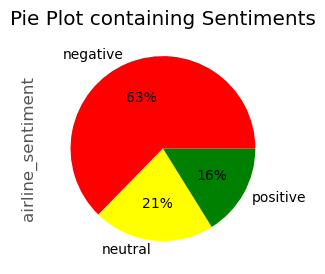

In [39]:
airline_tweets.airline_sentiment.value_counts().plot(kind='pie',
title='Pie Plot containing Sentiments', autopct='%1.0f%%',colors=["red", "yellow", "green"])

<AxesSubplot:title={'center':'Target class'}, xlabel='airline_sentiment'>

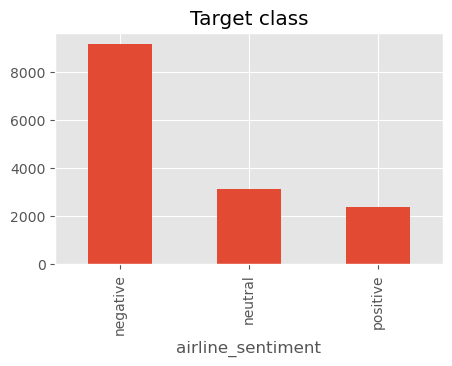

In [44]:
airline_tweets.groupby('airline_sentiment')['airline_sentiment'].count().plot(kind='bar',
title='Target class',
figsize=(5,3),
grid=True)

<AxesSubplot:xlabel='airline'>

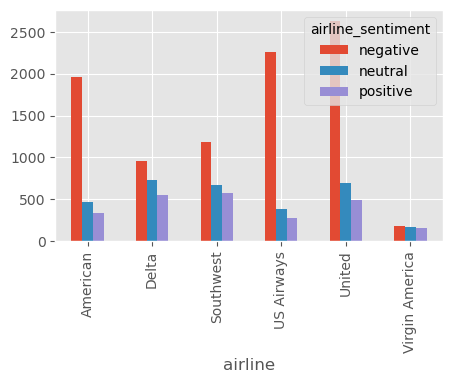

In [41]:
airline_sentiment = airline_tweets.groupby(['airline', 'airline_sentiment']).airline_sentiment.count().unstack()
airline_sentiment.plot(kind='bar')

<AxesSubplot:xlabel='airline_sentiment', ylabel='airline_sentiment_confidence'>

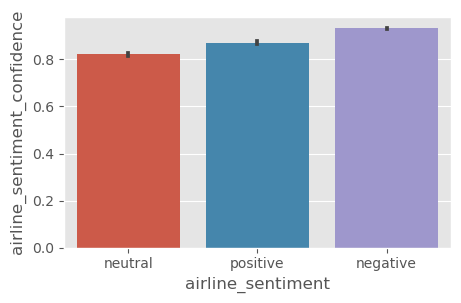

In [42]:
sns.barplot(x='airline_sentiment',
y='airline_sentiment_confidence' ,
data=airline_tweets)

Data Pre-Processing
Removing Punctuation, Numbers, Special Characters and Short Words

In [65]:
def remove_pattern(text, pattern):
    r = re.findall(pattern,text)
    for i in r:
        text = re.sub(i,"",text)
    return text

In [70]:
airline_tweets['text'] = np.vectorize(remove_pattern)(airline_tweets['text'], "@[\w]*")
airline_tweets.head(1)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,sentiment_class
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,What said,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),3


In [71]:
airline_tweets['text'] = airline_tweets['text'].str.replace("[^a-zA-Z#]", " ")
airline_tweets.head(1)

/var/folders/kk/lttwwrrj7jdf6km40smv8y8m0000gp/T/ipykernel_14785/3158794199.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  airline_tweets['text'] = airline_tweets['text'].str.replace("[^a-zA-Z#]", " ")


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,sentiment_class
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,What said,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),3
